# GNN Class Separability and Feature Analysis

This notebook assesses GNN class separability and reduces confusion in forest type classes using Linear Discriminant Analysis (LDA), Jeffries-Matusita (JM) distance, and Hierarchical Clustering.

## 1. Data Loading and Preprocessing

Initialize dataset environment and loads the tabular data containing spectral features and class labels. Align column names and map GNN classes to ODF forest types.

In [1]:
%load_ext cudf.pandas

In [ ]:
random_state = 0

In [3]:
import pandas as pd
import numpy as np
from forestvision.datasets import GNNForestAttr

# Initialize GNN dataset for remapping information
paths = "../data/datasets/gnn/2021/"
gnn = GNNForestAttr(paths=paths, remap=False, res=10, crs="EPSG:5070")
gnn.is_image = True 

# Load data
data = pd.read_csv('../data/fortypba/data_table_s2loff.csv', header=0).sample(3000000, random_state=random_state)
data.columns = ["label"] + data.columns[1:].to_list()
data['label'] = data.label.astype(float).astype(int)

# Map to ODF labels
data.insert(1, 'odf', data.label.replace(gnn.remap_dict))
print("Subset preview:", data[data.odf.isin([9,10,11])]['odf'].value_counts())

# Filter for specific classes
subset = data[data.odf.isin([10,11])][data.columns].drop("odf", axis=1).copy()
print(f"Subset shape: {subset.shape}")
subset.head()

Subset preview: odf
11    547441
9     281709
10    186165
Name: count, dtype: int64
Subset shape: (733606, 15)


,label,B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,B11,B12,B13,centroid
27035325,182,77.5,196.0,346.0,271.5,641.0,1343.0,1762.5,2178.5,2108.5,2148.5,1177.0,575.5,76.586708,3.875266e+17
27364956,182,34.5,117.0,278.0,148.0,597.0,2295.5,2929.5,3315.5,3264.0,2775.0,948.5,387.5,88.747787,3.617568e+17
104326,661,106.0,78.0,146.0,84.0,316.5,1272.5,1577.5,1581.5,1653.0,2140.5,511.5,228.5,894.732910,4.184503e+17
3269337,945,38.0,67.0,124.0,73.0,195.0,854.0,1217.0,1248.0,1375.0,1414.0,374.0,142.0,146.284943,6.967642e+17
16043278,661,39.5,141.5,232.5,213.0,538.5,1510.5,1824.5,1868.0,2142.5,2299.0,844.5,415.0,107.552452,1.129697e+18


## 2. Linear Discriminant Analysis (LDA)

### Methodology
LDA is a dimensionality reduction technique that maximizes the ratio of between-class variance to within-class variance. We use it to identify which spectral bands are most influential in distinguishing between forest types.

### Goal
Understand feature importance and project data into a lower-dimensional space that maximizes separability.

### Steps
1. Standardize features.
2. Fit the LDA model to the subset data.
3. Analyze explained variance and component loadings (scalings).
4. Project data onto the linear discriminants.

In [4]:
%load_ext cuml.accel

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def perform_lda_analysis(df: pd.DataFrame, class_label: str):
    """
    Performs LDA on the given dataset and plots the results in 2D.

    Args:
        df (pd.DataFrame): The DataFrame containing pixel data.
        class_label (str): The name of the column containing class labels.
    """
    try:
        # Separate features (X) and target (y)
        X = df.drop(class_label, axis=1)
        y = df[class_label]
        unique_labels = sorted(y.unique())

        # Standardize the features (important for LDA)
        X_scaled = StandardScaler().fit_transform(X)

        # --- Perform LDA ---
        # We set n_components=2 to project the data into a 2D space for plotting
        lda = LinearDiscriminantAnalysis(n_components=3)
        X_lda = lda.fit_transform(X_scaled, y)
        
        # Create a DataFrame for plotting LDA results
        lda_df = pd.DataFrame(X_lda, columns=[f'LD{i+1}' for i in range(X_lda.shape[1])])
        lda_df[class_label] = y.values

        print(f"Explained variance ratio of the 2 linear discriminants: {lda.explained_variance_ratio_}")
 
       # --- 1. Explained Variance Ratio ---
        print("\n1. Explained Variance Ratio:")
        print("This shows the proportion of the inter-class variance explained by each discriminant.")
        for i, ratio in enumerate(lda.explained_variance_ratio_):
            print(f"  - Linear Discriminant {i+1} (LD{i+1}): {ratio:.2%}")
            
        # --- 2. Component Loadings (Coefficients) ---
        print("\n2. LDA Component Loadings (Scalings):")
        print("This table shows the weight of each spectral band on the discriminant axes.")
        print("A high absolute value means the band is highly influential for that axis.")
        
        loadings_df = pd.DataFrame(
            lda.scalings_,
            index=X.columns,
            columns=[f'LD{i+1}' for i in range(len(lda.scalings_[0]))]
        )
        print(loadings_df.round(4))
        
        # --- Interpretation Helper ---
        print("\n--- Interpretation ---")
        for i in range(min(5, len(unique_labels) - 1)):
            ld_name = f'LD{i+1}'
            # Get the band with the highest absolute loading for this component
            most_influential_band = loadings_df[ld_name].abs().idxmax()
            print(f"For {ld_name}, the most influential band is '{most_influential_band}'.")
        
        # Visualize the LDA separation
        # sns.scatterplot(data=lda_df, x='LD1', y='LD2', palette='viridis', hue=class_label, s=100)
        # plt.title("Sites Projected onto LDA Axes")
        # plt.show()

    except FileNotFoundError:
        print(f"Error: The file '{df}' was not found.")
    except KeyError:
        print(f"Error: The CSV must contain a '{class_label}' column.")
        raise
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    finally:
        plt.close()
        return lda, lda_df

In [6]:
lda, lda_res = perform_lda_analysis(subset, class_label='label');

Explained variance ratio of the 2 linear discriminants: [0.37238807 0.2208792  0.17393675]

1. Explained Variance Ratio:
This shows the proportion of the inter-class variance explained by each discriminant.
  - Linear Discriminant 1 (LD1): 37.24%
  - Linear Discriminant 2 (LD2): 22.09%
  - Linear Discriminant 3 (LD3): 17.39%

2. LDA Component Loadings (Scalings):
This table shows the weight of each spectral band on the discriminant axes.
A high absolute value means the band is highly influential for that axis.
             LD1     LD2     LD3     LD4     LD5     LD6     LD7     LD8  \
B1       -0.4339 -0.2015 -0.0366  0.5334 -0.6712 -0.1485 -0.9242  0.4760   
B2        0.5139  0.4361 -1.1462 -1.9543 -1.1896  0.2211 -2.6509  4.0156   
B3       -1.1016 -0.4465  2.6422  2.1438  1.6536 -1.1602  0.7824 -9.6431   
B4        0.5494  0.1558 -1.2037  0.1276  0.0426  0.4841  1.1759  7.2954   
B5       -0.2916 -0.4475 -1.2866 -1.3779 -2.0542  2.0588  2.1126 -2.6772   
B6        0.7438  0.7728  1.

## 3. Jeffries-Matusita (JM) Distance Matrix

### Methodology
The JM distance is a parametric measure of separability between two classes. It ranges from 0 (identical distributions) to 2 (complete separability). We use it to identify specific class pairs that are highly confused.

### Goal
Quantify class separability using a statistical metric.

### Steps
1. Compute class-wise statistics (mean and covariance).
2. Calculate pairwise JM distances for all classes.
3. Identify the most similar (confused) classes.

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances
import warnings
from typing import Dict, Tuple, List, Callable


def compute_class_statistics(
    df: pd.DataFrame,
    class_column: str = 'class'
) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
    """
    Compute mean vector and covariance matrix for each class in the DataFrame.

    Args:
        df (pd.DataFrame): DataFrame with feature columns and a class label column.
            Shape: [N_samples, N_features + 1] where +1 is the class column.
        class_column (str): Name of the column containing class labels.

    Returns:
        Dict[str, Tuple[np.ndarray, np.ndarray]]: Dictionary mapping class labels
            to tuples of (mean, covariance) where:
            - mean: ndarray of shape [N_features]
            - covariance: ndarray of shape [N_features, N_features]

    Raises:
        ValueError: If class_column not found or no feature columns present.
    """
    if class_column not in df.columns:
        raise ValueError(f"Class column '{class_column}' not found in DataFrame. "
                        f"Available columns: {list(df.columns)}")

    feature_columns = [col for col in df.columns if col != class_column]
    if len(feature_columns) == 0:
        raise ValueError("No feature columns found in DataFrame.")

    class_stats = {}
    for label, group in df.groupby(class_column):
        n_samples = len(group)
        if n_samples < 2:
            warnings.warn(f"Class '{label}' has only {n_samples} sample(s). "
                         "Covariance will be regularized.")

        features = group[feature_columns].values
        mean = np.mean(features, axis=0)
        
        if n_samples >= 2:
            cov = np.cov(features, rowvar=False)
        else:
            cov = np.eye(len(feature_columns)) * 1e-3

        class_stats[label] = (mean, cov)

    return class_stats


def jeffries_matusita_metric(
    df: pd.DataFrame,
    class_column: str = 'class'
) -> Callable[[int, int], float]:
    """
    Create a custom JM distance metric function for use with pairwise_distances.

    Args:
        df (pd.DataFrame): Raw samples with feature columns and a class column.
            Shape: [N_samples, N_features + 1]
        class_column (str): Name of the column containing class labels.

    Returns:
        Callable[[int, int], float]: A metric function that takes indices i, j
            and returns JM distance in range [0, 2].
    """
    class_stats_dict = compute_class_statistics(df, class_column)

    class_labels = sorted(class_stats_dict.keys())
    means = [class_stats_dict[label][0] for label in class_labels]
    covs = [class_stats_dict[label][1] for label in class_labels]

    stats_lookup = {i: (means[i], covs[i]) for i in range(len(class_labels))}

    def jm_metric(i: int, j: int) -> float:
        """
        Compute JM distance between classes at indices i and j.

        Args:
            i (int): Index of first class.
            j (int): Index of second class.

        Returns:
            float: JM distance in range [0, 2].
        """
        mean1, cov1 = stats_lookup[i]
        mean2, cov2 = stats_lookup[j]

        if i == j:
            return 0.0

        n_features = len(mean1)
        cov1_reg = cov1 + np.eye(n_features) * 1e-6
        cov2_reg = cov2 + np.eye(n_features) * 1e-6

        pooled_cov = (cov1_reg + cov2_reg) / 2
        diff = mean1 - mean2

        try:
            inv_pooled_cov = np.linalg.inv(pooled_cov)
        except np.linalg.LinAlgError:
            inv_pooled_cov = np.linalg.pinv(pooled_cov)

        term1 = 0.125 * diff.T @ inv_pooled_cov @ diff

        det_cov1 = np.linalg.det(cov1_reg)
        det_cov2 = np.linalg.det(cov2_reg)
        det_pooled = np.linalg.det(pooled_cov)
        # det_sum = np.linalg.det(cov1_reg + cov2_reg)

        if det_cov1 <= 0 or det_cov2 <= 0 or det_pooled <= 0:
            warnings.warn("Non-positive determinant encountered. Using stronger regularization.")
            cov1_reg = cov1 + np.eye(n_features) * 1e-3
            cov2_reg = cov2 + np.eye(n_features) * 1e-3
            det_cov1 = np.linalg.det(cov1_reg)
            det_cov2 = np.linalg.det(cov2_reg)
            det_pooled = np.linalg.det(pooled_cov)

        term2 = 0.5 * np.log(det_pooled / (np.sqrt(det_cov1) * np.sqrt(det_cov2)))

        B = term1 + term2
        JM = 2 * (1 - np.exp(-B))

        return np.clip(JM, 0, 2)

    return jm_metric


def compute_jm_matrix_with_sklearn(
    df: pd.DataFrame,
    class_column: str = 'class'
) -> Tuple[np.ndarray, List]:
    """
    Compute JM distance matrix using sklearn's pairwise_distances approach.

    Args:
        df (pd.DataFrame): Raw samples with feature columns and a class column.
            Shape: [N_samples, N_features + 1]
        class_column (str): Name of the column containing class labels.

    Returns:
        Tuple[np.ndarray, List]:
            - jm_matrix: Symmetric distance matrix of shape [N_classes, N_classes].
              Values range from 0 (identical) to 2 (completely separable).
            - class_labels: Sorted list of class labels corresponding to matrix indices.

    Example:
        >>> df = pd.DataFrame({
        ...     'band1': [0.2, 0.3, 0.8, 0.9],
        ...     'band2': [0.1, 0.2, 0.7, 0.8],
        ...     'class': ['oak', 'oak', 'pine', 'pine']
        ... })
        >>> jm_matrix, labels = compute_jm_matrix_with_sklearn(df)
        >>> print(labels)
        ['oak', 'pine']
    """
    class_stats_dict = compute_class_statistics(df, class_column)

    class_labels = sorted(class_stats_dict.keys())
    n_classes = len(class_labels)

    indices = np.arange(n_classes).reshape(-1, 1)

    jm_metric_func = jeffries_matusita_metric(df, class_column)

    def metric_wrapper(x: np.ndarray, y: np.ndarray) -> float:
        """Wrapper to convert array indices to scalar indices."""
        i = int(x[0])
        j = int(y[0])
        return jm_metric_func(i, j)

    jm_matrix = pairwise_distances(indices, metric=metric_wrapper)

    return jm_matrix, class_labels 

In [31]:
# %%timeit
jm_matrix, class_labels = compute_jm_matrix_with_sklearn(lda_res, class_column='label')
jm_df = pd.DataFrame(jm_matrix, index=class_labels, columns=class_labels)
# jm_df.head(20)

/tmp/ipykernel_13514/653215322.py:41: UserWarning: Class '982' has only 1 sample(s). Covariance will be regularized.
  warnings.warn(f"Class '{label}' has only {n_samples} sample(s). "


In [9]:
print("\n" + "="*50)
print("JM Distance Matrix")
print("="*50)
print(f"\nClass labels: {len(class_labels)}\n")
print(jm_df[jm_df.columns[:10]].round(2))
print("\n" + "="*50)

# Find min and max distance pairs
mask = jm_matrix > 0
min_val = jm_matrix[mask].min()
min_indices = np.where(jm_matrix == min_val)
min_pairs = [(class_labels[i], class_labels[j]) for i, j in zip(min_indices[0], min_indices[1])]
print(f"Min JM distance: {min_val:.4f} between classes: {min_pairs[0]}")

max_val = jm_matrix.max()
max_indices = np.where(jm_matrix == max_val)
max_pairs = [(class_labels[i], class_labels[j]) for i, j in zip(max_indices[0], max_indices[1])]
print(f"Max JM distance: {max_val:.4f} between classes: {max_pairs[0]}")



JM Distance Matrix

Class labels: 109

      35    42    43    67    68    69    123   170   177   182
35   0.00  0.03  0.35  0.21  0.38  0.28  0.21  0.13  0.64  0.62
42   0.03  0.00  0.31  0.27  0.40  0.26  0.21  0.19  0.59  0.48
43   0.35  0.31  0.00  0.28  0.08  0.04  0.77  0.39  1.31  1.10
67   0.21  0.27  0.28  0.00  0.21  0.23  0.65  0.16  1.13  1.01
68   0.38  0.40  0.08  0.21  0.00  0.08  0.81  0.32  1.37  1.22
..    ...   ...   ...   ...   ...   ...   ...   ...   ...   ...
946  0.89  0.75  0.92  1.04  1.06  0.89  0.77  0.95  0.91  0.49
947  0.68  0.54  0.67  0.82  0.82  0.66  0.62  0.78  0.80  0.47
948  0.79  0.66  0.83  0.95  0.95  0.79  0.65  0.86  0.80  0.47
969  1.72  1.65  1.96  1.86  1.99  1.94  1.65  1.83  1.70  1.38
982  1.99  1.99  2.00  2.00  2.00  2.00  1.99  2.00  2.00  1.98

[109 rows x 10 columns]

Min JM distance: 0.0083 between classes: (684, 703)
Max JM distance: 1.9999 between classes: (68, 982)


## 4. Hierarchical Clustering

### Methodology
Using the JM distance matrix as a distance metric, we perform hierarchical clustering to group classes that are statistically similar. This helps in remapping GNN classes into more distinct aggregate groups.

### Goal
Identify clusters of confused classes to guide remapping.

### Steps
1. Convert JM matrix to condensed form.
2. Perform hierarchical clustering with complete linkage.
3. Assign classes to a specified number of clusters.
4. Merge cluster labels back to the dataset.

In [25]:
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Perform hierarchical clustering
jm_condensed = squareform(jm_matrix)
linked = linkage(jm_condensed, method='complete')

# Extract clusters
n_clusters = 5
cluster = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='complete')
cluster_labels = cluster.fit_predict(jm_matrix)

clustered = pd.DataFrame({'cluster': cluster_labels}, index=class_labels)
lda_res['cluster'] = lda_res['label'].replace(clustered['cluster'].to_dict())

print("Cluster Assignments:")
print(lda_res.head())
print(f"\nUnique clusters in lda_res: {lda_res['cluster'].unique()}")

Cluster Assignments:
        LD1       LD2       LD3  label  cluster
0 -1.816510  0.811397 -0.870510    182        0
1 -0.567356  1.794645 -0.571370    182        0
2  0.546316  2.050392  1.406252    661        1
3 -0.252616  0.218636 -1.302215    945        1
4 -0.474358 -0.311244 -0.786821    661        1

Unique clusters in lda_res: [0 1 4 2 3]


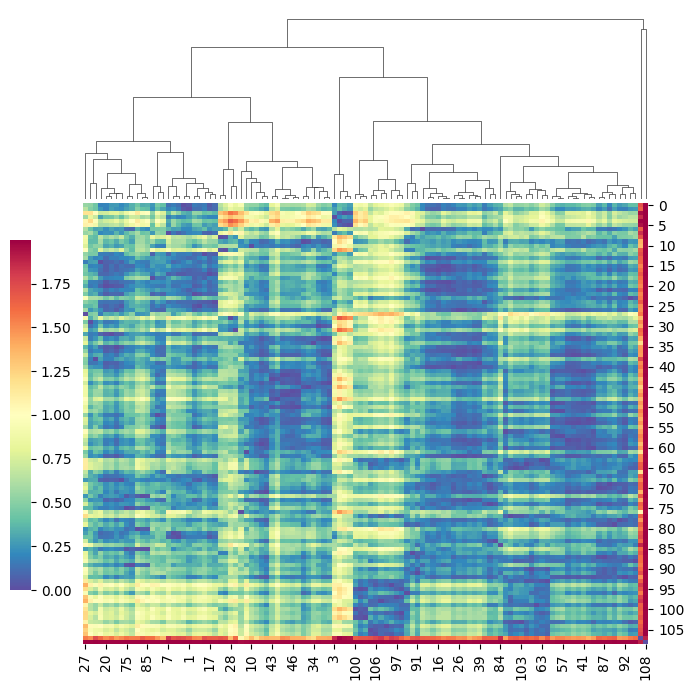

In [26]:
from cudf.pandas.module_accelerator import disable_module_accelerator

# 2. Use the context manager to disable cudf.pandas for the plotting section
with disable_module_accelerator():
    # Plot
    g = sns.clustermap(
        jm_df,
        row_linkage=linked,
        col_linkage=linked,
        cmap='Spectral_r',
        figsize=(7, 7),
        row_cluster=False,
        dendrogram_ratio=(0.1, 0.3),
        cbar_pos=(0.015, .15, .03, .5)
    )
    # g.figure.suptitle('JM Distance Matrix with Hierarchical Clustering', y=1.02, fontsize=12)
    plt.show()

In [27]:
clustered.groupby('cluster').size()

cluster
0    48
1    55
2     1
3     1
4     4
dtype: int64

In [28]:
lda_res.groupby('cluster').size()

cluster
0    226062
1    505722
2       379
3         1
4      1442
dtype: int64

## 5. Classification and Evaluation

### Methodology
We train a Support Vector Classifier (SVC) on the clustered labels to evaluate how well the newly defined groups can be separated using the features.

### Goal
Assess the classifier performance before and after remapping/clustering.

### Steps
1. Prepare features and target (cluster labels).
2. Split into training and testing sets.
3. Train a LinearSVC.
4. Evaluate with a classification report and accuracy score.

In [29]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# Prepare data
X = lda_res.drop(['cluster', 'label'], axis=1)
y = lda_res['cluster'].astype(int)

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=random_state)

# Train
clf = LinearSVC(penalty='l1', loss='squared_hinge', max_iter=10000)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7019

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.14      0.22     44988
           1       0.71      0.95      0.82    101374
           2       0.00      0.00      0.00        79
           4       0.00      0.00      0.00       281

    accuracy                           0.70    146722
   macro avg       0.32      0.27      0.26    146722
weighted avg       0.67      0.70      0.63    146722



In [30]:
lda_res.head()

,LD1,LD2,LD3,label,cluster
0,-1.816510,0.811397,-0.870510,182,0
1,-0.567356,1.794645,-0.571370,182,0
2,0.546316,2.050392,1.406252,661,1
3,-0.252616,0.218636,-1.302215,945,1
4,-0.474358,-0.311244,-0.786821,661,1
